In [ ]:
# ===============================
# INSTALL JAVA + SPARK (FAST WAY)
# ===============================

!apt-get install openjdk-11-jdk-headless -qq

# install pyspark directly (FASTER than manual spark download)
!pip install pyspark==3.5.1

import os
os.environ["JAVA_HOME"]="/usr/lib/jvm/java-11-openjdk-amd64"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NYC_Taxi_Assignment") \
    .config("spark.driver.memory","6g") \
    .config("spark.sql.shuffle.partitions","8") \
    .config("spark.default.parallelism","8") \
    .getOrCreate()

print("Spark Ready ✅")

Spark Ready ✅


In [ ]:
df = spark.read.parquet("/content/yellow_tripdata_2019-07.parquet")

df.printSchema()
df.show(5)

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: integer (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+---

In [ ]:
df.count()

6310419

In [ ]:
from pyspark.sql.functions import col

df2 = df.select(
    "trip_distance",
    "passenger_count",
    "fare_amount",
    "tip_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID",
    "total_amount"
).dropna()

df2.cache()
df2.show(5)

+-------------+---------------+-----------+----------+------------+------------+------------+------------+
|trip_distance|passenger_count|fare_amount|tip_amount|payment_type|PULocationID|DOLocationID|total_amount|
+-------------+---------------+-----------+----------+------------+------------+------------+------------+
|          0.0|            1.0|        2.5|      1.14|           1|         193|         193|        4.94|
|         4.16|            1.0|       16.5|       0.0|           2|         234|          25|        20.3|
|         18.8|            1.0|       52.0|     11.75|           1|         132|          42|       70.67|
|        18.46|            1.0|       52.0|     11.06|           1|         132|         142|       66.36|
|          1.7|            0.0|        9.5|       2.0|           1|         107|         114|        15.3|
+-------------+---------------+-----------+----------+------------+------------+------------+------------+
only showing top 5 rows



In [ ]:
df_clean = df2.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") > 0) &
    (col("total_amount") > 0) &
    (col("passenger_count") > 0)
)

df_clean.count()

6081550

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "trip_distance",
        "passenger_count",
        "fare_amount",
        "tip_amount",
        "payment_type",
        "PULocationID",
        "DOLocationID"
    ],
    outputCol="features"
)

data = assembler.transform(df_clean).select("features","total_amount")
data.show(5)

+--------------------+------------+
|            features|total_amount|
+--------------------+------------+
|[4.16,1.0,16.5,0....|        20.3|
|[18.8,1.0,52.0,11...|       70.67|
|[18.46,1.0,52.0,1...|       66.36|
|[2.4,1.0,13.0,3.3...|       20.15|
|[3.0,1.0,12.5,0.0...|        16.3|
+--------------------+------------+
only showing top 5 rows



In [ ]:
train, test = data.randomSplit([0.8,0.2], seed=42)

In [ ]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="total_amount"
)

lr_model = lr.fit(train)
lr_pred = lr_model.transform(test)

In [ ]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="total_amount"
)

dt_model = dt.fit(train)
dt_pred = dt_model.transform(test)

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_amount",
    numTrees=20
)

rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

In [ ]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="total_amount",
    maxIter=20
)

gbt_model = gbt.fit(train)
gbt_pred = gbt_model.transform(test)

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="total_amount",
    predictionCol="prediction",
    metricName="rmse"
)

print("Linear Regression RMSE:", evaluator.evaluate(lr_pred))
print("Decision Tree RMSE:", evaluator.evaluate(dt_pred))
print("Random Forest RMSE:", evaluator.evaluate(rf_pred))
print("GBT RMSE:", evaluator.evaluate(gbt_pred))

Linear Regression RMSE: 1.5214036137471079
Decision Tree RMSE: 4.794764854409392
Random Forest RMSE: 4.686878000669262
GBT RMSE: 4.534528698186827


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

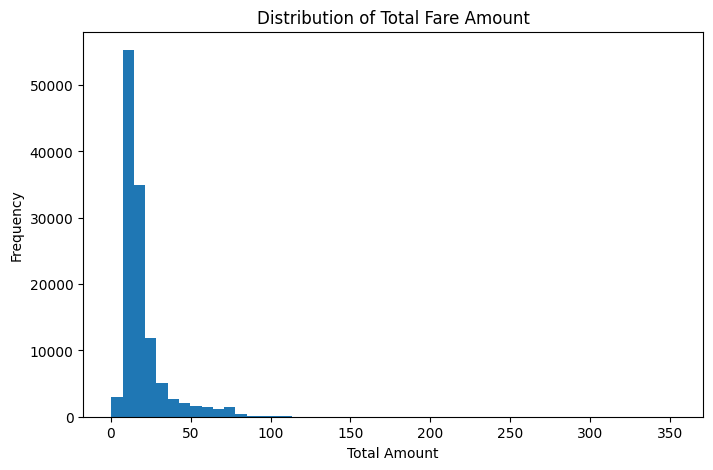

In [ ]:
sample_df = df_clean.select("total_amount").sample(0.02).toPandas()

plt.figure(figsize=(8,5))
plt.hist(sample_df["total_amount"], bins=50)
plt.title("Distribution of Total Fare Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

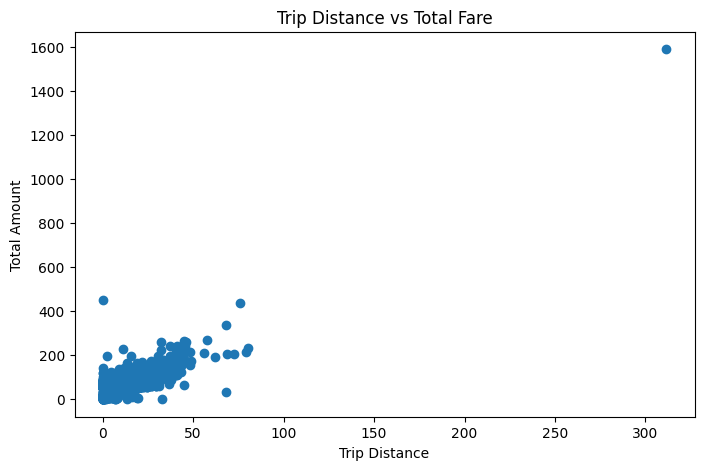

In [ ]:
scatter_df = df_clean.select(
    "trip_distance","total_amount"
).sample(0.02).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(scatter_df["trip_distance"],
            scatter_df["total_amount"])
plt.title("Trip Distance vs Total Fare")
plt.xlabel("Trip Distance")
plt.ylabel("Total Amount")
plt.show()

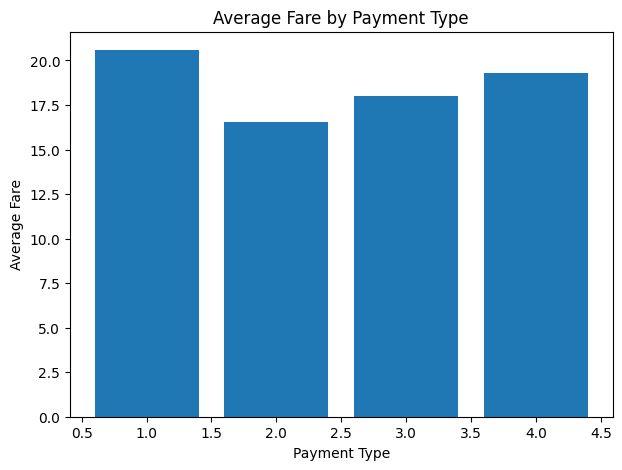

In [ ]:
payment_avg = df_clean.groupBy("payment_type") \
    .avg("total_amount") \
    .toPandas()

plt.figure(figsize=(7,5))
plt.bar(payment_avg["payment_type"],
        payment_avg["avg(total_amount)"])

plt.title("Average Fare by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Fare")
plt.show()

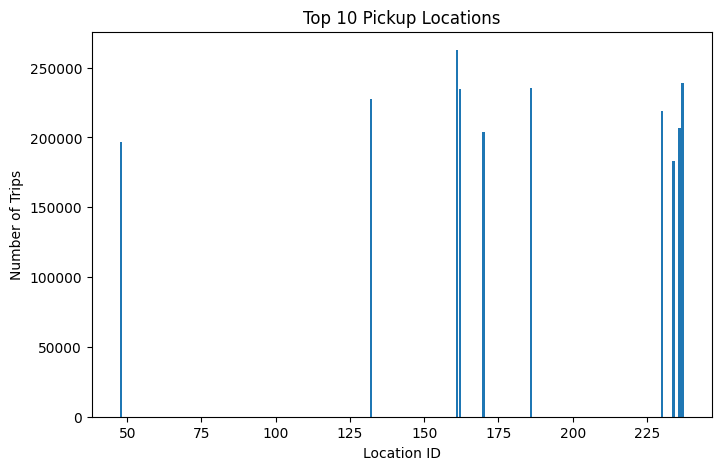

In [ ]:
top_locations = df_clean.groupBy("PULocationID") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(top_locations["PULocationID"],
        top_locations["count"])

plt.title("Top 10 Pickup Locations")
plt.xlabel("Location ID")
plt.ylabel("Number of Trips")
plt.show()

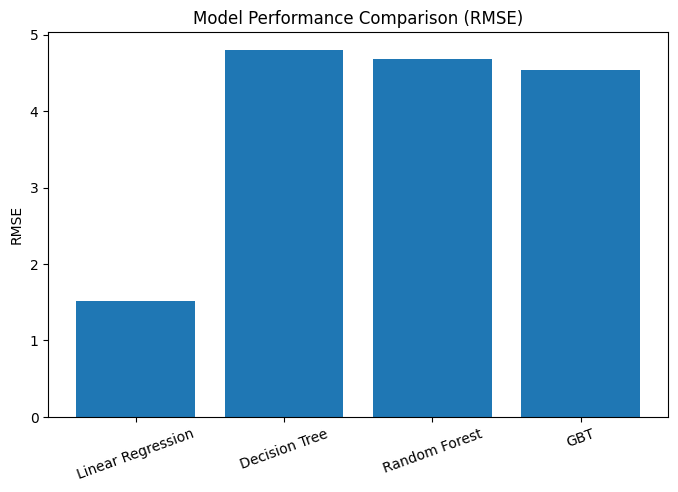

In [ ]:
models = ["Linear Regression","Decision Tree",
          "Random Forest","GBT"]

rmse_values = [
    evaluator.evaluate(lr_pred),
    evaluator.evaluate(dt_pred),
    evaluator.evaluate(rf_pred),
    evaluator.evaluate(gbt_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_values)
plt.title("Model Performance Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

In [ ]:
print("Partitions:", data.rdd.getNumPartitions())

Partitions: 8


In [ ]:
rf_pred.select("prediction","total_amount").write.mode("overwrite").csv("/content/output_predictions")

In [ ]:
df_clean.groupBy("payment_type","PULocationID") \
    .avg("total_amount") \
    .write.mode("overwrite") \
    .csv("/content/tableau_data", header=True)